# LLM Evaluation with RAG
Comparing standard LLM translation vs RAG-enhanced translation using COMET, BLEU, and TER metrics.

In [1]:
import pandas as pd
import torch
import time
import os
import re
import ast
from tqdm.notebook import tqdm
from typing import Tuple, List

# LangChain & Chroma
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings, OllamaLLM
from langchain_core.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableSequence

# RAG Utils
from difflib import SequenceMatcher

# Evaluation
from evaluate import load
import matplotlib.pyplot as plt

# Check GPU
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")
    torch.set_float32_matmul_precision('high')


CUDA available: True
Device: NVIDIA GeForce RTX 4070 SUPER


In [2]:
# Configuration
# MODELS = ["gemma2:9b", "gemma3:4b", "gemma3:4b-it-qat", "thinkverse/towerinstruct:latest"]
MODELS = ["gemma2:9b", "gemma3:4b-it-qat", "thinkverse/towerinstruct:latest"]
TEMPERATURE = 0.3
RAG_PATH = "../rag"
DATA_PATH = "../data/corpus/csv/merged_foreo_uniques.csv"
OUTPUT_DIR = "../data/rag_test/csv/"
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [3]:
# Load Data
print(f"Loading data from {DATA_PATH}...")
df_base = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df_base)} segments.")
df_base.head()


Loading data from ../data/corpus/csv/merged_foreo_uniques.csv...
Loaded 956 segments.


,english,spanish,endpoint
0,This website uses cookies,Esta página web usa cookies,bestsellers
1,"We use cookies to personalise content and ads,...",Las cookies de este sitio web se usan para per...,bestsellers
2,Necessary,Necesario,bestsellers
3,Preferences,Preferencias,bestsellers
4,Statistics,Estadística,bestsellers


In [4]:
# Initialize Vector DB
print(f"Initializing ChromaDB from {RAG_PATH}...")
embeddings = OllamaEmbeddings(model="nomic-embed-text")
vector_db = Chroma(
    persist_directory=RAG_PATH,
    embedding_function=embeddings,
    collection_name="foreo_translations"
)
print("Vector DB initialized.")


Initializing ChromaDB from ../rag...
Vector DB initialized.


In [5]:
def clean_segment(text):
    if pd.isna(text):
        return ""
    text = str(text).strip()
    text = re.sub(r'\s+', ' ', text)
    return text

def retrieve_context(segment, k=5):
    results = vector_db.similarity_search(segment, k=k)
    context_pairs = []
    for d in results:
        src = d.page_content
        tgt = d.metadata.get("target", None)
        if tgt:
            context_pairs.append((src, tgt))
    return context_pairs

def best_match_score(segment, context_pairs):
    best_score = 0.0
    best_target = None
    for src, tgt in context_pairs:
        score = SequenceMatcher(None, segment.lower(), src.lower()).ratio()
        if score > best_score:
            best_score = score
            best_target = tgt
    return best_score, best_target


In [6]:
def llm_translation(model_name, data, temp):
    system_template = (
        "You are a professional translator from English to Spanish from Spain. "
        "Translate the exact text provided by the user, regardless of its content or format. "
        "Do not add any explanations, questions, or comments. "
        "Return only the final Spanish translation."
    )
    human_template = "{text}"
    
    llm = OllamaLLM(model=model_name, temperature=temp)
    prompt = ChatPromptTemplate.from_messages([
        SystemMessagePromptTemplate.from_template(system_template),
        HumanMessagePromptTemplate.from_template(human_template),
    ])
    chain = prompt | llm
    
    translations = []
    start_time = time.time()
    
    for text in tqdm(data["english"], desc=f"Standard: {model_name}"):
        if pd.isna(text) or not str(text).strip():
            translations.append("")
        else:
            try:
                res = chain.invoke({"text": text})
                translations.append(res)
            except Exception as e:
                translations.append(f"ERROR: {e}")
                
    elapsed = time.time() - start_time
    return translations, elapsed


In [7]:
def rag_translation_process(model_name, data, temp, similarity_threshold=0.92):
    llm = OllamaLLM(model=model_name, temperature=temp)
    
    translations = []
    start_time = time.time()
    
    for segment in tqdm(data["english"], desc=f"RAG: {model_name}"):
        if pd.isna(segment) or not str(segment).strip():
            translations.append("")
            continue
            
        # 1. Retrieve Context
        context_pairs = retrieve_context(segment, k=5)
        score, best_target = best_match_score(segment, context_pairs)
        
        # 2. Case A: Strong match -> Reuse
        if score >= similarity_threshold and best_target:
            translations.append(best_target)
            continue
            
        # 3. Case B: Weak match -> Few-shot prompt
        context_text = "\n".join([f"- Source: {src}\n  Target: {tgt}" for src, tgt in context_pairs])
        
        prompt = f"""
        You are a professional translator for the brand FOREO.
        Translate the text into Spanish, following the vocabulary, tone and wording style used in the examples.
        
        ### Style Examples
        {context_text}
        
        ### Task
        Translate the following text to Spanish.
        Follow the style and terminology of the examples.
        Do NOT add explanations.
        Return only the translation.
        
        Text to translate:
        '''{segment}'''
        """
        
        try:
            res = llm.invoke(prompt).strip()
            translations.append(res)
        except Exception as e:
            translations.append(f"ERROR: {e}")
            
    elapsed = time.time() - start_time
    return translations, elapsed


In [8]:
results_df = df_base.copy()
elapsed_times = {}

for model in MODELS:
    # Standard
    print(f"Running Standard Translation for {model}...")
    std_trans, std_time = llm_translation(model, df_base, TEMPERATURE)
    col_std = f"{model}_std"
    results_df[col_std] = [clean_segment(t) for t in std_trans]
    elapsed_times[col_std] = std_time
    
    # RAG
    print(f"Running RAG Translation for {model}...")
    rag_trans, rag_time = rag_translation_process(model, df_base, TEMPERATURE)
    col_rag = f"{model}_rag"
    results_df[col_rag] = [clean_segment(t) for t in rag_trans]
    elapsed_times[col_rag] = rag_time

# Save Translations
output_file = os.path.join(OUTPUT_DIR, "rag_test_translations.csv")
results_df.to_csv(output_file, index=False)
print(f"Saved translations to {output_file}")

# Save Times
time_file = os.path.join(OUTPUT_DIR, "rag_test_times.csv")
pd.DataFrame([elapsed_times]).to_csv(time_file, index=False)
print(f"Saved times to {time_file}")


Running Standard Translation for gemma2:9b...


Standard: gemma2:9b:   0%|          | 0/956 [00:00<?, ?it/s]

Running RAG Translation for gemma2:9b...


RAG: gemma2:9b:   0%|          | 0/956 [00:00<?, ?it/s]

Running Standard Translation for gemma3:4b-it-qat...


...

Running Standard Translation for thinkverse/towerinstruct:latest...


Standard: thinkverse/towerinstruct:latest:   0%|          | 0/956 [00:00<?, ?it/s]

Running RAG Translation for thinkverse/towerinstruct:latest...


RAG: thinkverse/towerinstruct:latest:   0%|          | 0/956 [00:00<?, ?it/s]

Saved translations to ../data/rag_test/csv/rag_test_translations.csv
Saved times to ../data/rag_test/csv/rag_test_times.csv


In [9]:
# Load Metrics
print("Loading metrics...")
comet_metric = load("comet", device="cuda" if torch.cuda.is_available() else "cpu")
ter_metric = load("ter")
bleu_metric = load("bleu")

def compute_metrics(df, model_col):
    sources = df["english"].tolist()
    refs = df["spanish"].tolist()
    preds = df[model_col].tolist()
    
    # COMET
    comet_res = comet_metric.compute(sources=sources, predictions=preds, references=refs)
    comet_score = round(comet_res["mean_score"], 4)
    
    # TER
    ter_res = ter_metric.compute(predictions=preds, references=refs, case_sensitive=True)
    ter_score = round(ter_res["score"], 2)
    
    # BLEU
    bleu_res = bleu_metric.compute(predictions=preds, references=refs)
    bleu_score = round(bleu_res["bleu"] * 100, 2) # Usually reported as 0-100
    
    return comet_score, ter_score, bleu_score


Loading metrics...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

C:\Python_repositories\foreo-ai-engineering-project\.venv\Lib\site-packages\comet\models\__init__.py:101: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Encoder model frozen.
C:\Python_repositories\foreo-ai-engineering-project\.venv\Lib\site-packages\pytorch_lightning\core\saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']


In [10]:
metrics_data = []

model_cols = [c for c in results_df.columns if c not in ["english", "spanish", "endpoint"]]

for col in model_cols:
    print(f"Evaluating {col}...")
    c_score, t_score, b_score = compute_metrics(results_df, col)
    
    # Parse model name and type
    if "_rag" in col:
        m_name = col.replace("_rag", "")
        m_type = "RAG"
    else:
        m_name = col.replace("_std", "")
        m_type = "Standard"
        
    metrics_data.append({
        "Model": m_name,
        "Type": m_type,
        "COMET": c_score,
        "TER": t_score,
        "BLEU": b_score,
        "Latency": elapsed_times.get(col, 0)
    })

metrics_df = pd.DataFrame(metrics_data)
metrics_file = os.path.join(OUTPUT_DIR, "rag_test_metrics.csv")
metrics_df.to_csv(metrics_file, index=False)
print(metrics_df)


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Evaluating gemma2:9b_std...


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Evaluating gemma2:9b_rag...


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Evaluating gemma3:4b-it-qat_rag...


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Evaluating thinkverse/towerinstruct:latest_std...


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Evaluating thinkverse/towerinstruct:latest_rag...
                             Model      Type   COMET     TER   BLEU  \
0                        gemma2:9b  Standard  0.8593   60.78  35.40   
1                        gemma2:9b       RAG  0.9472    5.84  93.78   
2                 gemma3:4b-it-qat  Standard  0.8603   60.17  34.02   
3                 gemma3:4b-it-qat       RAG  0.9476    5.77  93.82   
4  thinkverse/towerinstruct:latest  Standard  0.8063  101.19  22.38   
5  thinkverse/towerinstruct:latest       RAG  0.9316    6.96  92.64   

      Latency  
0  536.046002  
1   81.827001  
2  395.314396  
3   94.898114  
4  426.666451  
5   58.923078  


In [27]:
# Plotting
def plot_metric(df, metric, title):
    pivot = df.pivot(index="Model", columns="Type", values=metric)
    ax = pivot.plot(kind="bar", figsize=(10, 6), rot=45)

    # Title + labels
    plt.title(title)
    plt.ylabel(metric)

    # Grid
    ax.grid(True, axis="y", linestyle="--", alpha=0.6)

    # Set Y-axis limits depending on metric
    m = metric.upper()
    if m == "COMET":
        ax.set_ylim(0, 1.0)
    elif m == "BLEU":
        ax.set_ylim(0, 100)
    elif m == "TER":
        ax.set_ylim(0, 110)
    elif m == "LATENCY":
        ax.set_ylim(0, 700)

    # Add value annotations above bars
    for container in ax.containers:
        if m == "COMET":
            fmt = "%.3f"
        elif m in ["BLEU", "TER"]:
            fmt = "%.1f"
        else:
            fmt = "%.2f"  # Latency
        ax.bar_label(container, fmt=fmt, padding=3)

    # Legend outside on the right
    ax.legend(title="Type", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

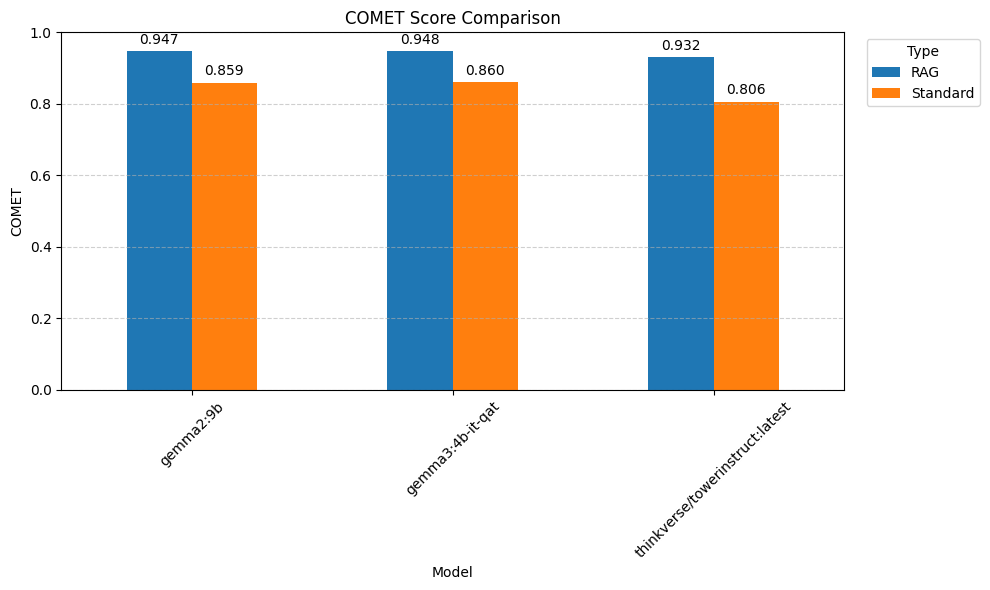

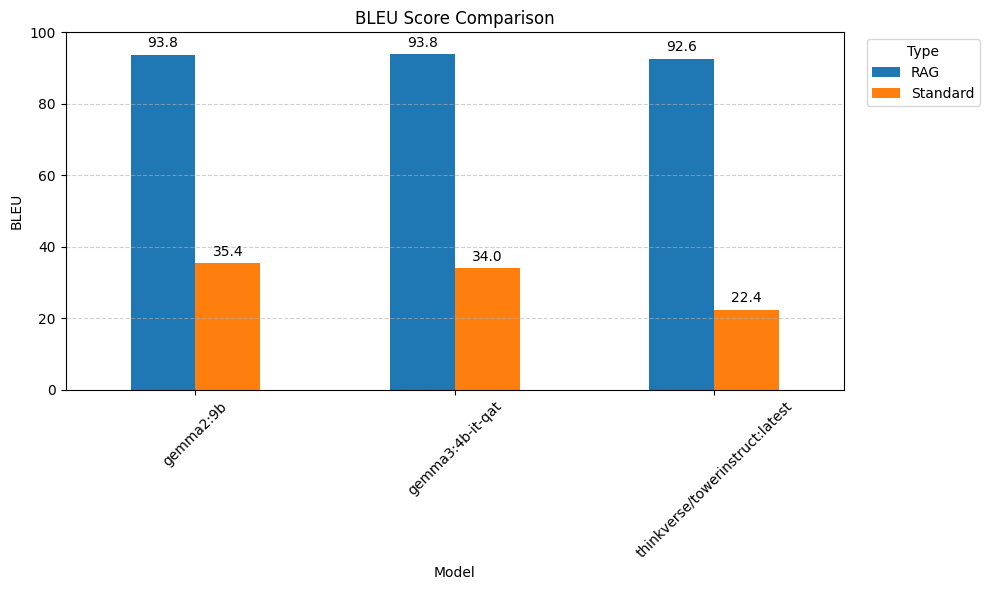

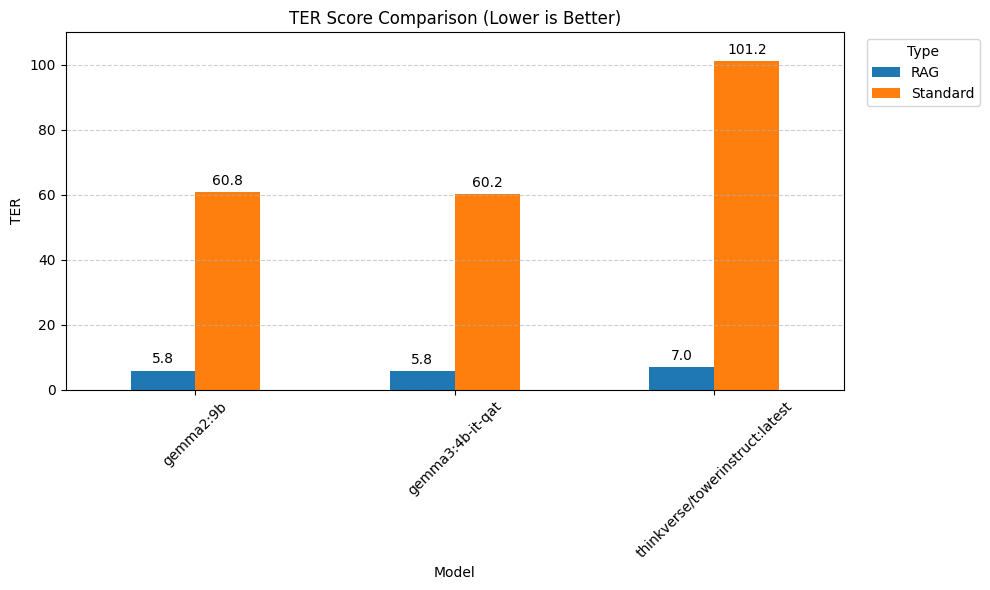

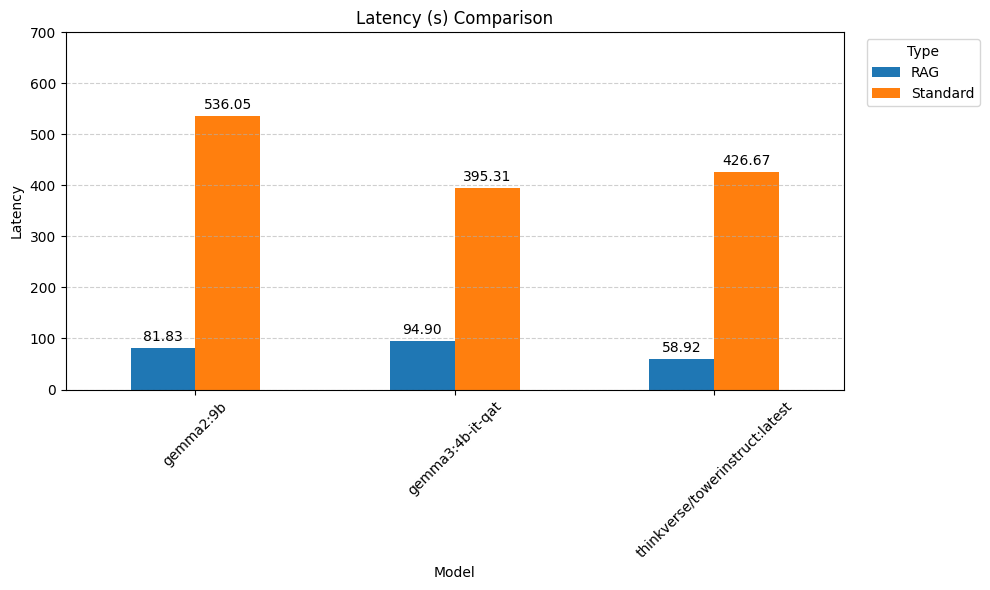

In [28]:
plot_metric(metrics_df, "COMET", "COMET Score Comparison")
plot_metric(metrics_df, "BLEU", "BLEU Score Comparison")
plot_metric(metrics_df, "TER", "TER Score Comparison (Lower is Better)")
plot_metric(metrics_df, "Latency", "Latency (s) Comparison")